# I. Introduction

Final Project - RiskBeacon

- Batch : HCK-037

# II. Project Libraries

In [3]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats
from scipy.stats import kendalltau, pearsonr, spearmanr

# Preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.utils.class_weight import compute_class_weight

# Model selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold,
    learning_curve,
    cross_validate
)

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    RocCurveDisplay,
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

import xgboost as xgb
import lightgbm as lgb

# Outlier handling
from feature_engine.outliers import Winsorizer

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Model Saving
import pickle

# III. Data Loading

## 3.1. Loading Dataset from CSV

In [259]:
# Melakukan loading dataset dari file CSV
df = pd.read_csv("cs-training.csv")
df

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [260]:
# Modifying in place
df.drop('Unnamed: 0', axis=1, inplace=True)
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


## 3.2. Handling Duplicated Data

### 3.2.1. Checking Duplicated Data Amount

In [261]:
# Jumlah data yang merupakan duplikasi dari data lain
df.duplicated().sum()

609

### 3.2.2. Deleting Duplicated Data

In [262]:
df = df.drop_duplicates()
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


## 3.3. Backing Up Dataframe

In [263]:
# Melakukan backup terhadap dataframe
df_backup = df.copy()

Backup dilakukan supaya kita dapat tetap mengakses dataframe original sebelum dilakukan cleaning.

## 3.4. Analyzing Dataset

In [264]:
# Display jumlah data dan tipe data dari setiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149391 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      149391 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  149391 non-null  float64
 2   age                                   149391 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  149391 non-null  int64  
 4   DebtRatio                             149391 non-null  float64
 5   MonthlyIncome                         120170 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       149391 non-null  int64  
 7   NumberOfTimes90DaysLate               149391 non-null  int64  
 8   NumberRealEstateLoansOrLines          149391 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  149391 non-null  int64  
 10  NumberOfDependents                    145563 non-null  float64
dtypes: fl

Insight:
- **Total data:** 149,391  
- **Total fitur:** 11  
- Semua fitur numerik
  - `int64`: 7 kolom (counts, discrete)
  - `float64`: 4 kolom (continuous)

Sebagian besar data berupa kuantitatif, maka dataset termasuk jenis tabular yang tidak memerlukan encoding.

Kolom target:
- **`SeriousDlqin2yrs`**
  - Type: `int64`
  - Binary classification target (0 = no default, 1 = default)

In [265]:
# Numerical statistical summary
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,149391.000000,149391.000000,149391.000000,149391.000000,149391.000000,1.201700e+05,149391.000000,149391.000000,149391.000000,149391.000000,145563.000000
mean,0.066999,6.071087,52.306237,0.393886,354.436740,6.675098e+03,8.480892,0.238120,1.022391,0.212503,0.759863
std,0.250021,250.263672,14.725962,3.852953,2041.843455,1.438958e+04,5.136515,3.826165,1.130196,3.810523,1.116141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030132,41.000000,0.000000,0.177441,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154235,52.000000,0.000000,0.368234,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.556494,63.000000,0.000000,0.875279,8.250000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


- Target: **`SeriousDlqin2yrs`** : rata-rata 6,7%, terdapat data imbalance.

- **`RevolvingUtilization`** : Mean 6,07, Median 0,15, Max 50.000, ditangani dengan Log transform dan winsorization
- **`DebtRatio`** : Mean 354, Median 0,37, Max 329.000, ditangani dengan Log transform dan cap nilai ekstrem
- **`MonthlyIncome`** : Right-skewed + missing values, ditangani dengan Log transform dan imputasi

- **Delinquency vars** (`30/60/90 days late`) : Mayoritas bernilai 0, max 98, terdapat anomali data, ditangani dengan capping 0–10 dan buat binary flag `HasLate`
- **`NumberOfDependents`** : mayoritas bernilai 0 dan terdapat nilai ekstrim, ditangani dengan capping.

- **`age`** : nilai 0 (invalid), Max 109 (ekstrem), perlu dilakukan validasi dan imputasi
- **Delinquency features** : nilai 96–98 (artefak data) perlu dilakukan capping

# IV. Exploratory Data Analysis

## 4.1. Target Distribution

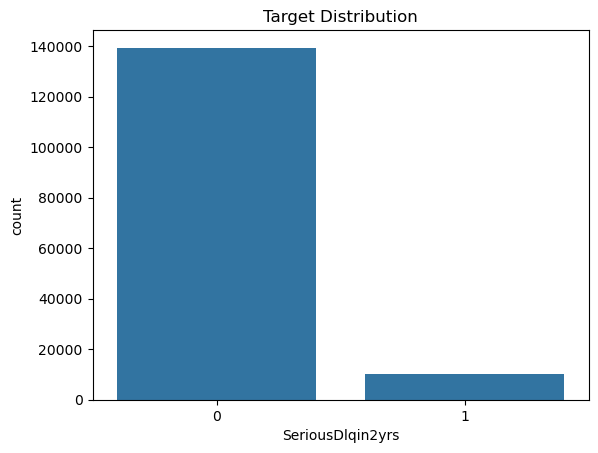

In [266]:
sns.countplot(x="SeriousDlqin2yrs", data=df)
plt.title("Target Distribution")
plt.show()

Gunakan class weighting untuk membantu performa algoritma yang rentan terhadap class imbalance. 

Untuk penelitian kali ini:
- Logistic Regression
- MLP (Multi-Layer Perceptron)
- Random Forest

## 4.2. Distribution of Continuous Columns

### 4.2.1. DebtRatio and RevolvingUtilizationOfUnsecuredLines

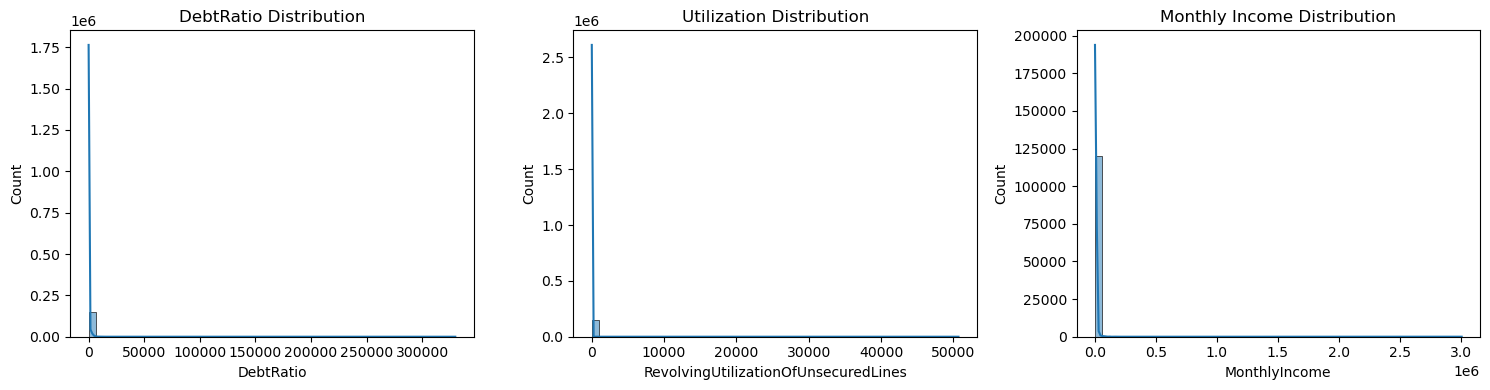

In [267]:
plt.figure(figsize=(15, 4))

# DebtRatio
plt.subplot(1, 3, 1)
sns.histplot(df["DebtRatio"], bins=50, kde=True)
plt.title("DebtRatio Distribution")

# Utilization
plt.subplot(1, 3, 2)
sns.histplot(df["RevolvingUtilizationOfUnsecuredLines"], bins=50, kde=True)
plt.title("Utilization Distribution")

# MonthlyIncome
plt.subplot(1, 3, 3)
sns.histplot(df["MonthlyIncome"], bins=50, kde=True)
plt.title("Monthly Income Distribution")

plt.tight_layout()
plt.show()

Ketiga fitur menunjukkan distribusi mereka memiliki skew ekstrim kanan, dapat ditangani dengan melakukan log transform atau winsorize.

## 4.3. Outlier Detection

### 4.3.1. Late Payment

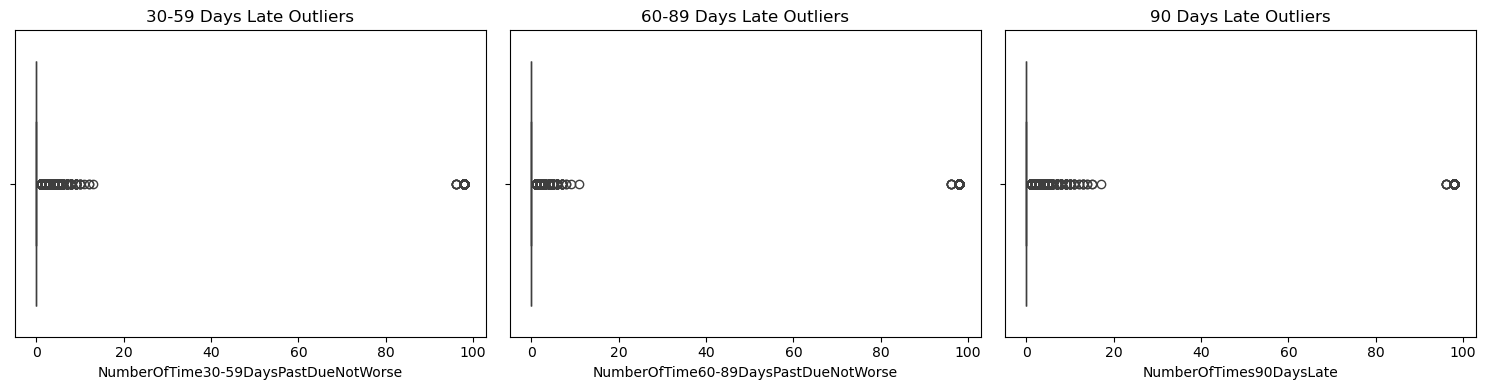

In [268]:
# Outlier Detection
plt.figure(figsize=(15, 4))

# 30-59 Days
plt.subplot(1, 3, 1)
sns.boxplot(x=df["NumberOfTime30-59DaysPastDueNotWorse"])
plt.title("30-59 Days Late Outliers")

# 60 - 89 Days
plt.subplot(1, 3, 2)
sns.boxplot(x=df["NumberOfTime60-89DaysPastDueNotWorse"])
plt.title("60-89 Days Late Outliers")

# 90 Days
plt.subplot(1, 3, 3)
sns.boxplot(x=df["NumberOfTimes90DaysLate"])
plt.title("90 Days Late Outliers")

plt.tight_layout()
plt.show()

- Nilai lebih banyak terkonsentrasi pada 0
- Terdapat nilai ekstrim yang melebihi 90 seperti 96 dan 98

Mayoritas distribusi data terdapat di < 10. Perlu dilakukan pembatasan/capping terhadap nilai yang lebih dari 10.

## 4.4. Feature correlation to Target

### 4.4.1. `DebtRatio`

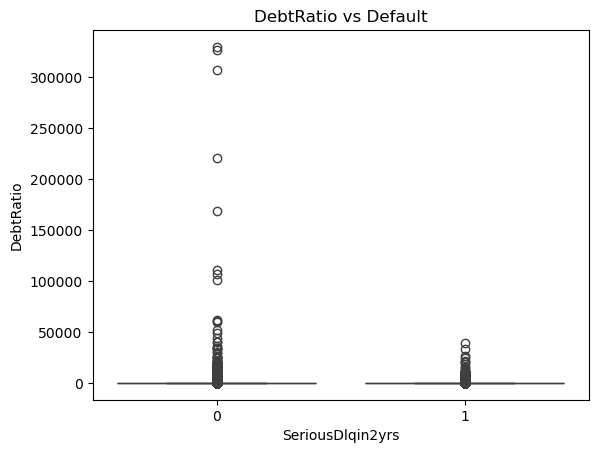

In [269]:
sns.boxplot(x="SeriousDlqin2yrs", y="DebtRatio", data=df)
plt.title("DebtRatio vs Default")
plt.show()

Distribusi memiliki skew ekstrim, di mana konsentrasi nilai mendekati 0 and dan terdapat beberapa nilai outlier yang melebihi 300.000.

### 4.4.2 `RevolvingUtilizationOfUnsecuredLines`

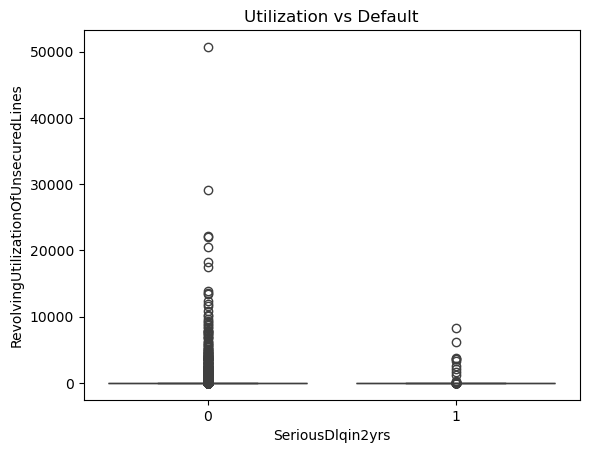

In [270]:
sns.boxplot(x="SeriousDlqin2yrs", y="RevolvingUtilizationOfUnsecuredLines", data=df)
plt.title("Utilization vs Default")
plt.show()

Distribusi memiliki skew ekstrim, di mana konsentrasi nilai mendekati 0 and dan terdapat beberapa nilai outlier yang melebihi 50.000.

Sehingga untuk kedua kolom ini dapat ditangani dengan melakukan log transform.

## 4.5. Default Rate

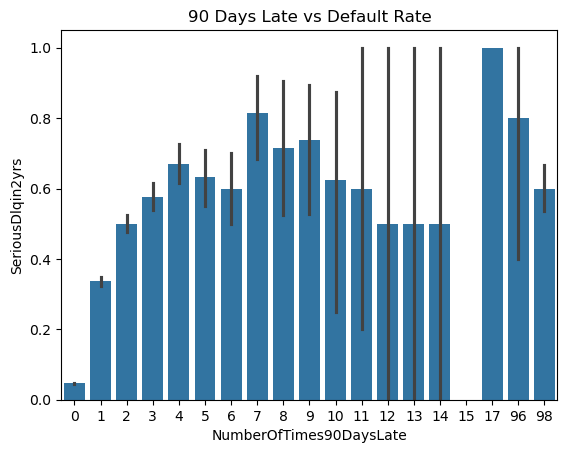

In [271]:
sns.barplot(
    x="NumberOfTimes90DaysLate",
    y="SeriousDlqin2yrs",
    data=df
)
plt.title("90 Days Late vs Default Rate")
plt.show()

- **90 Days Late vs Default Rate**: risiko default meningkat tajam seiring jumlah keterlambatan
  - 0 late: risiko rendah, 1–3: lonjakan besar, 4–10: risiko tinggi konsisten
  - Nilai >10 tidak stabil, kemungkinan anomali data (misal: 96, 98)
  - Fitur prediktif kuat dengan tren yang jelas
  - Dilakukan clipping nilai 0–10, buat binary flag `Has90Late`

## 4.6. Correlation 

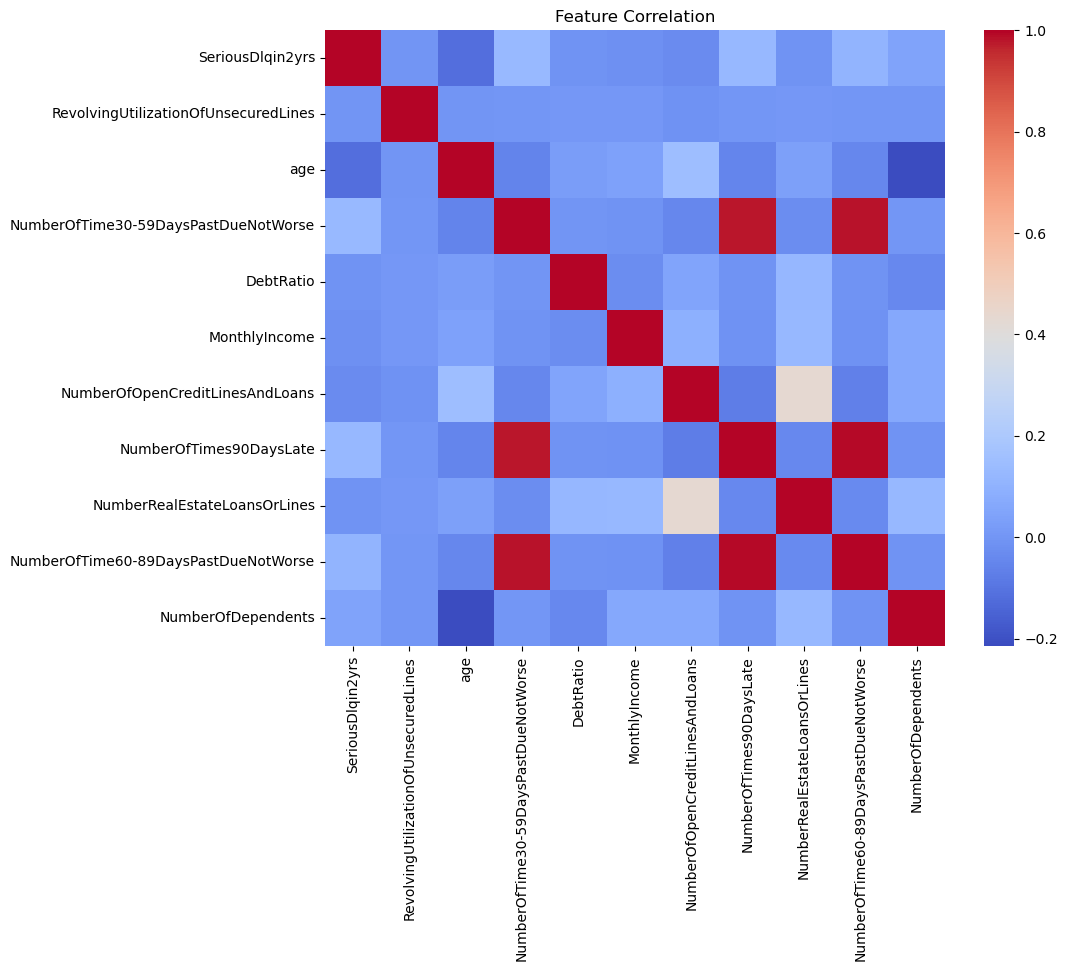

In [272]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

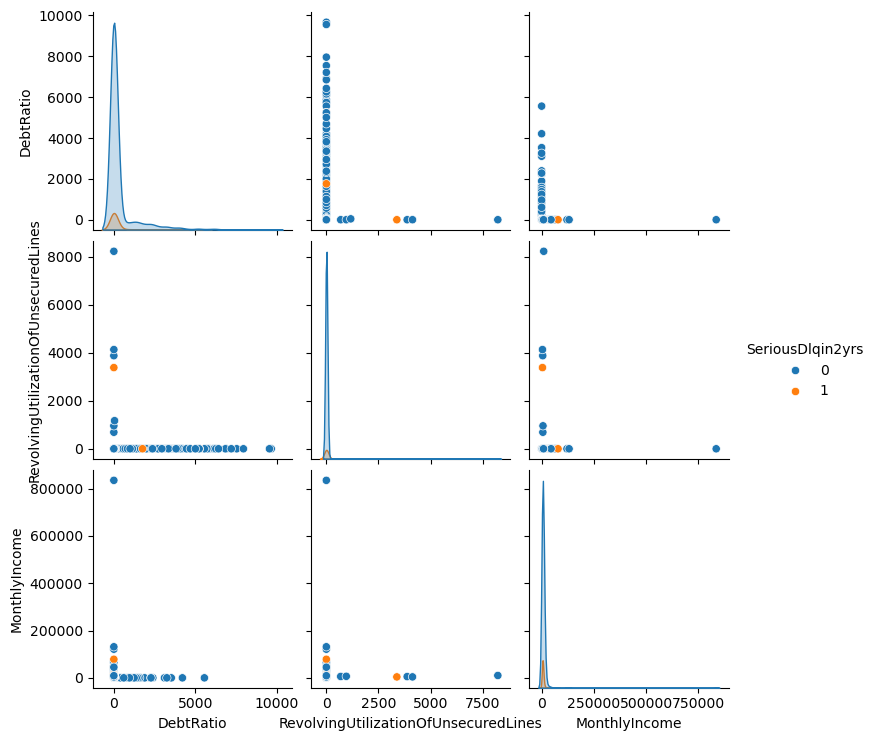

In [273]:
sns.pairplot(
    df.sample(2000),
    vars=[
        "DebtRatio",
        "RevolvingUtilizationOfUnsecuredLines",
        "MonthlyIncome"
    ],
    hue="SeriousDlqin2yrs"
)

## 4.7 Data Quality

In [274]:
# Age issues
(df["age"] < 18).sum()

1

In [275]:
# Extreme delinquency
(df["NumberOfTimes90DaysLate"] > 50).sum()

225

- **Kesimpulan EDA**
  - **Penanganan missing values** : imputasi median/grouped, tambah flag missing
  - **Penanganan outlier** : log transform (`DebtRatio`, `Utilization`, `Income`), cap nilai delinquency
  - **Data cleaning** : perbaiki rentang `age`, hapus nilai tidak valid
  - **Feature engineering** : agregasi keterlambatan pembayaran, interaksi debt-income, binary risk indicator

# V. Feature Engineering

In [276]:
# Penyalinan dataframe khusus yang akan dilakukan feature engineering
df_fe = df.copy()

## 5.1. Handling Missing Value

In [277]:
df_fe.isna().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29221
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3828
dtype: int64

- **Penanganan missing value**
  - Imputasi `MonthlyIncome` dengan median atau grouped median
  - Imputasi `NumberOfDependents` dengan median
  - Tambahkan binary flag untuk nilai yang hilang

<Axes: >

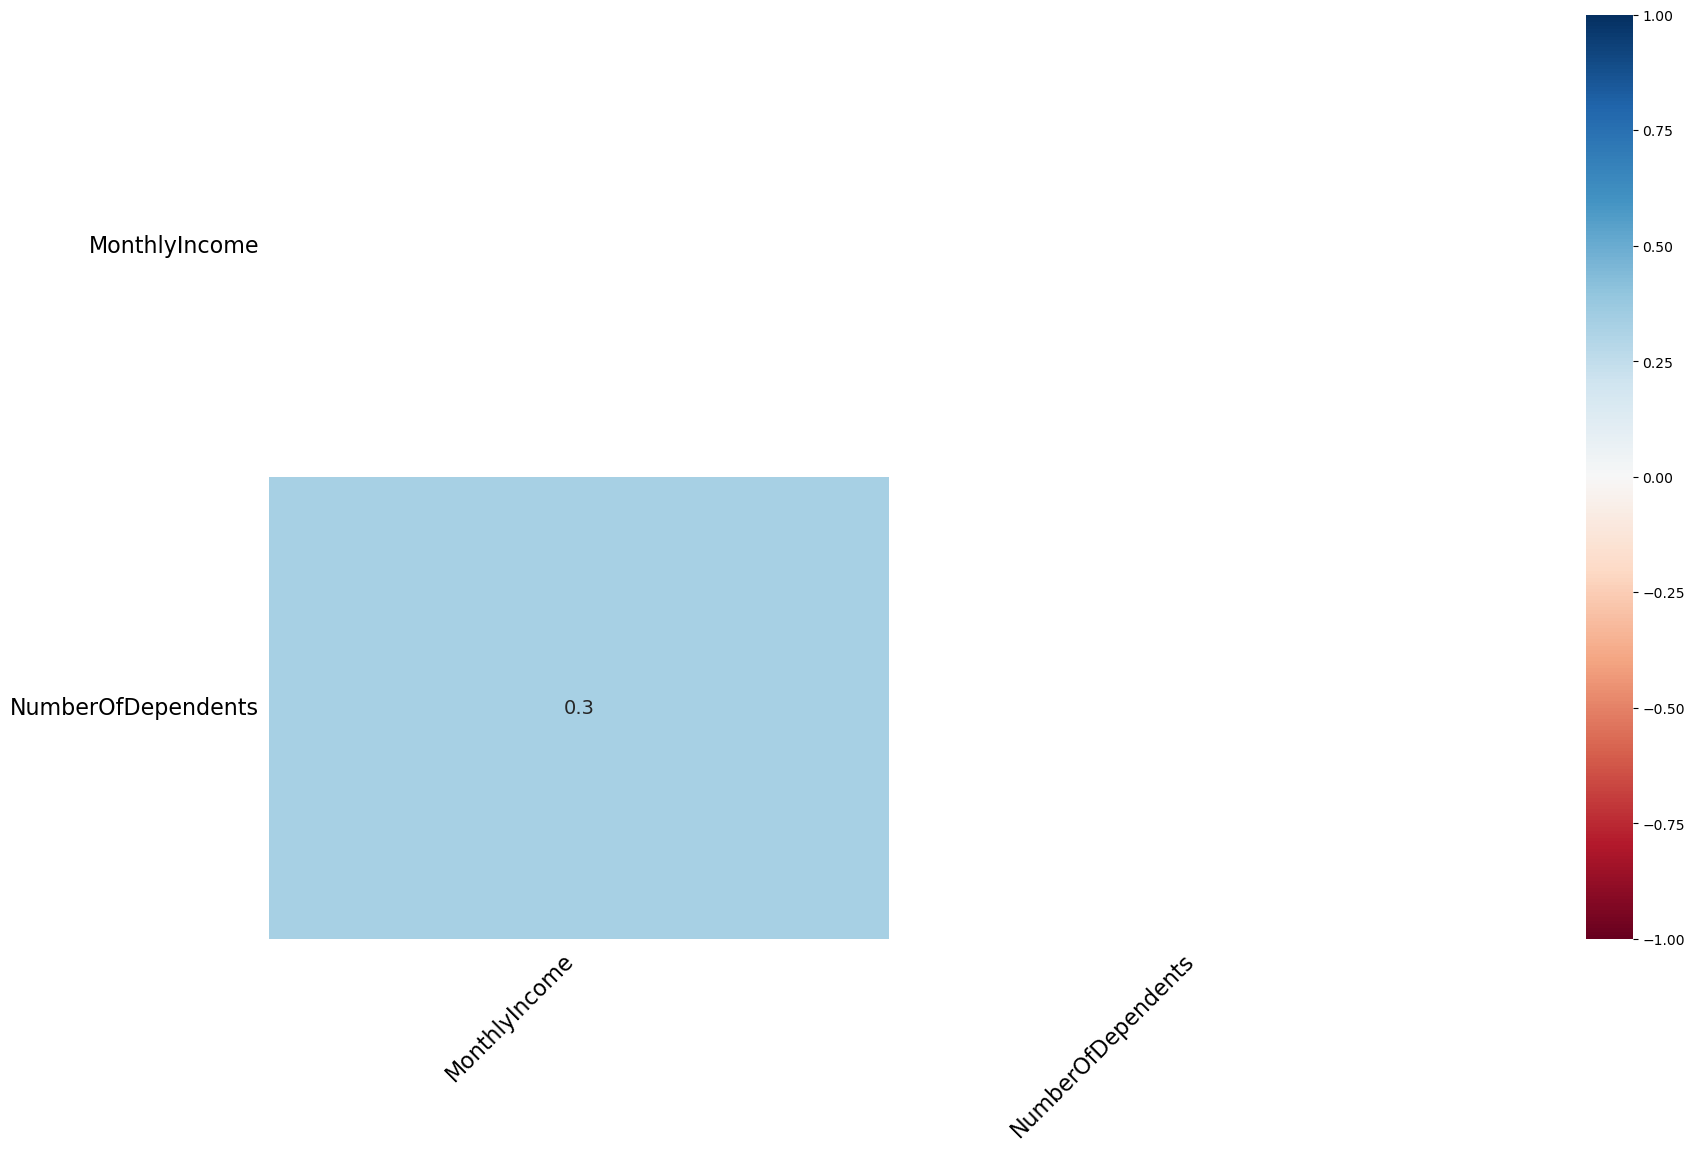

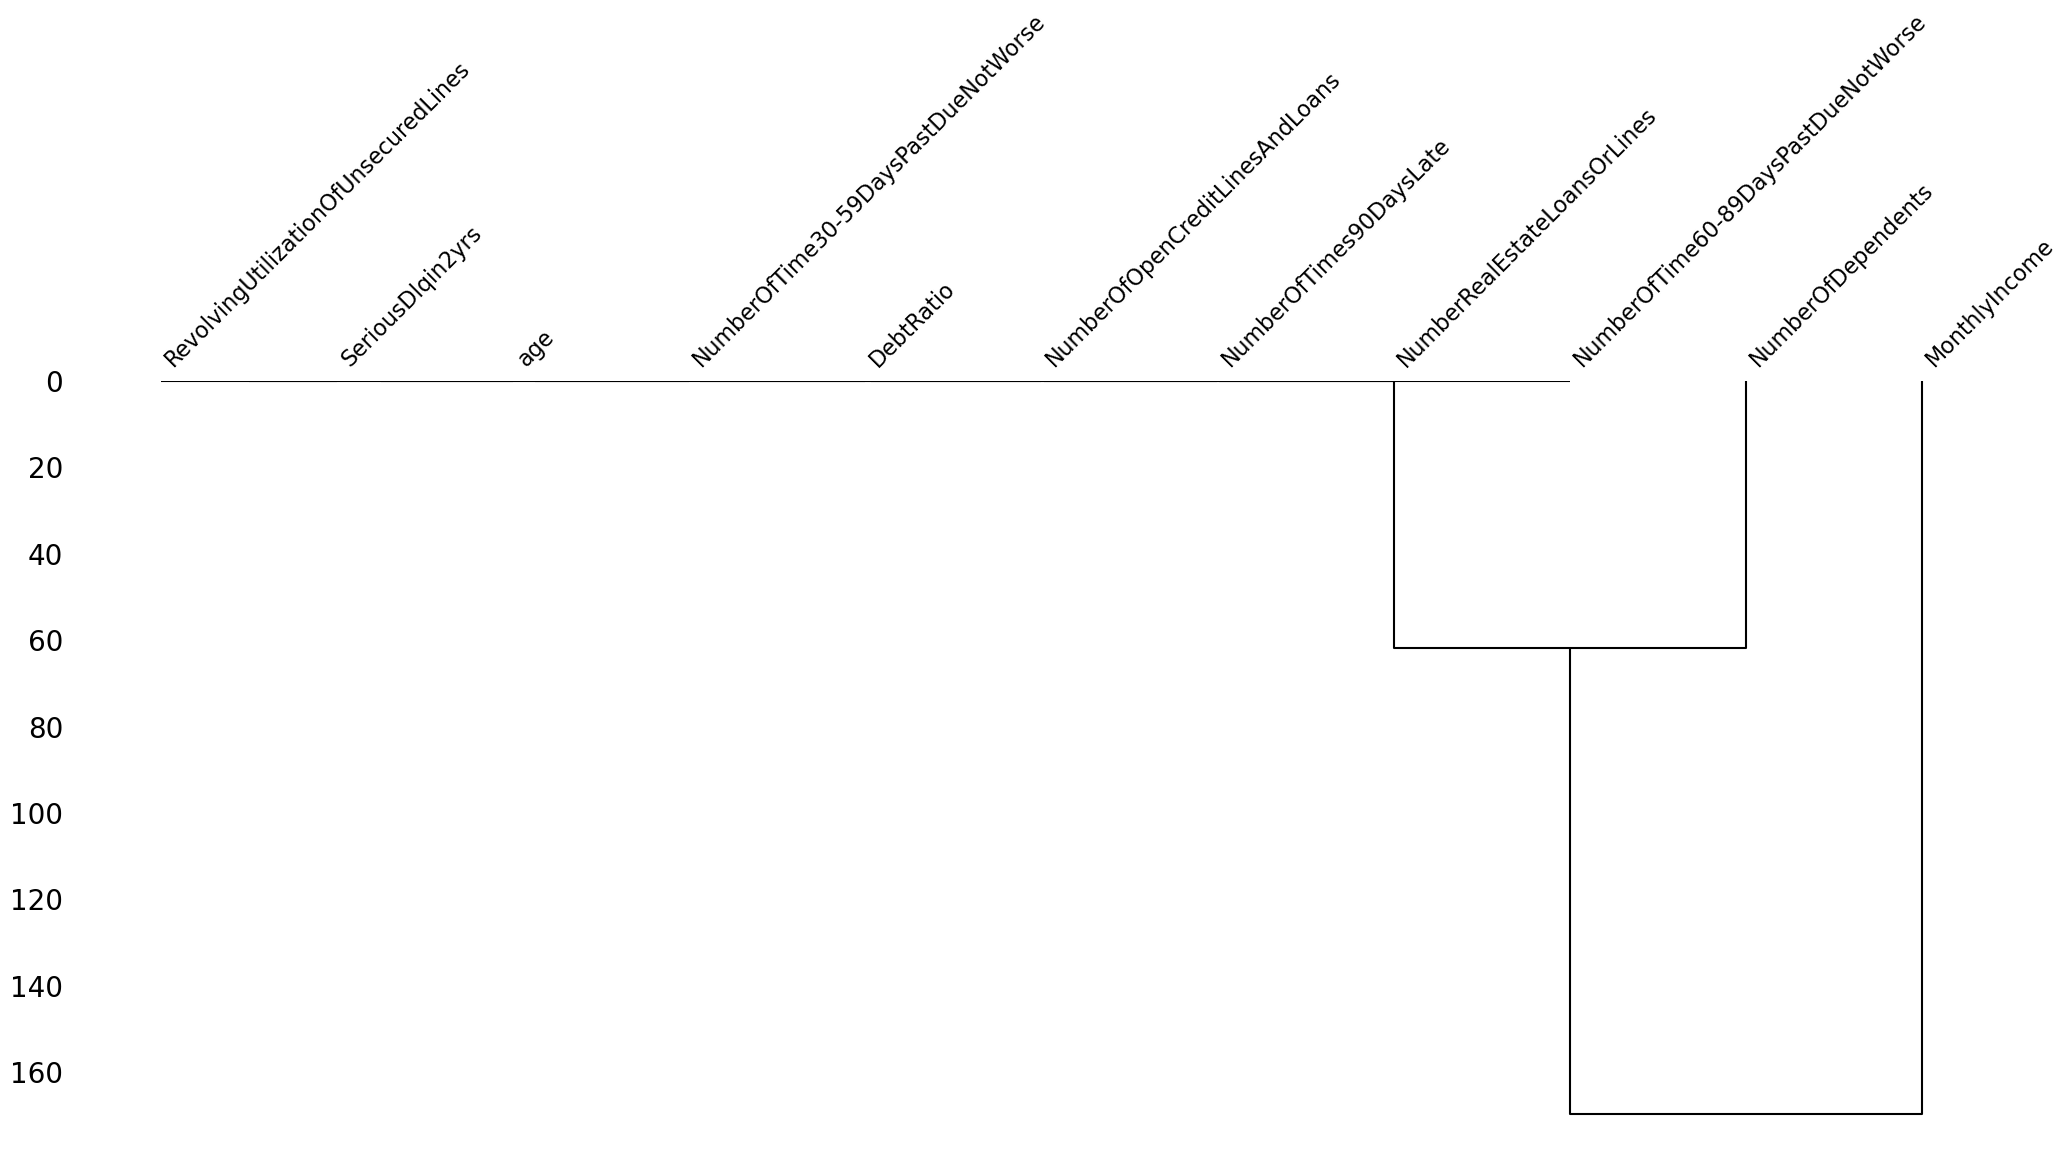

In [278]:
import missingno as msno

# 1. Visualize missingness correlation heatmap
msno.heatmap(df_fe)

# 2. Visualize missingness clusters with a dendrogram
msno.dendrogram(df_fe)


In [279]:
# Flagging datas with missing value
df_fe["IncomeMissingFlag"] = df_fe["MonthlyIncome"].isnull().astype(int)
df_fe["DependentsMissingFlag"] = df_fe["NumberOfDependents"].isnull().astype(int)

# Imputing missing value with median
df_fe["MonthlyIncome"].fillna(df_fe["MonthlyIncome"].median(), inplace=True)
df_fe["NumberOfDependents"].fillna(df_fe["NumberOfDependents"].median(), inplace=True)

df_fe.isna().sum()

C:\Users\Konenhizer\AppData\Local\Temp\ipykernel_18996\1972567922.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fe["MonthlyIncome"].fillna(df_fe["MonthlyIncome"].median(), inplace=True)
C:\Users\Konenhizer\AppData\Local\Temp\ipykernel_18996\1972567922.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
IncomeMissingFlag                       0
DependentsMissingFlag                   0
dtype: int64

## 5.2. Handling Outlier

### 5.2.1 Pengelompokan Fitur

- **Fitur kontinu** : fitur dengan distribusi numerik berkelanjutan yang rentan terhadap skewness dan outlier
  - `RevolvingUtilizationOfUnsecuredLines`
  - `DebtRatio`
  - `MonthlyIncome`

- **Fitur count** : fitur berbasis hitungan dengan distribusi diskrit dan zero-inflated
  - `NumberOfTime30-59DaysPastDueNotWorse`
  - `NumberOfTime60-89DaysPastDueNotWorse`
  - `NumberOfTimes90DaysLate`
  - `NumberOfOpenCreditLinesAndLoans`
  - `NumberRealEstateLoansOrLines`
  - `NumberOfDependents`

In [ ]:
# Kolom Continuous
continuous_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "MonthlyIncome"
]

# Kolom Count
count_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents"
]

### 5.2.2 Winsorization Fitur Continuous

- Clipping nilai fitur kontinu pada batas **persentil 1% dan 99%** untuk mengurangi pengaruh outlier ekstrem
- Diterapkan pada: `RevolvingUtilizationOfUnsecuredLines`, `DebtRatio`, `MonthlyIncome`

In [281]:
for col in continuous_cols:
    lower = df_fe[col].quantile(0.01)
    upper = df_fe[col].quantile(0.99)
    df_fe[col] = df_fe[col].clip(lower, upper)

### 5.2.3 Log Transformasi `RevolvingUtilizationOfUnsecuredLines`

- Diterapkan `log1p` untuk mengurangi skewness ekstrem pada fitur utilisasi kredit

In [282]:
df_fe["RevolvingUtilizationOfUnsecuredLines"] = np.log1p(df_fe["RevolvingUtilizationOfUnsecuredLines"])

### 5.2.4 Capping Fitur Count

- Clipping nilai fitur count pada rentang **0–10** untuk menghilangkan nilai anomali seperti 96 dan 98

In [283]:
for col in count_cols:
    df_fe[col] = df_fe[col].clip(0, 10)

### 5.2.5 Filter Nilai `age` Tidak Valid

- Mempertahankan hanya observasi dengan rentang usia **18–100 tahun** untuk menghilangkan nilai tidak valid

In [284]:
df_fe = df_fe[(df["age"] >= 18) & (df_fe["age"] <= 100)]

In [285]:
df_fe.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,IncomeMissingFlag,DependentsMissingFlag
count,149377.000000,149377.000000,149377.000000,149377.000000,149377.000000,149377.000000,149377.000000,149377.000000,149377.000000,149377.000000,149377.000000,149377.000000,149377.000000
mean,0.066998,0.245521,52.302115,0.261366,317.887327,6149.591845,7.085669,0.105351,1.019394,0.080032,0.740355,0.195572,0.025606
std,0.250020,0.246436,14.718202,0.793535,908.913168,3844.480764,2.886485,0.613667,1.088861,0.507444,1.107242,0.396642,0.157958
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029691,41.000000,0.000000,0.177446,3900.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.143448,52.000000,0.000000,0.368232,5400.000000,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.442455,63.000000,0.000000,0.875062,7400.000000,10.000000,0.000000,2.000000,0.000000,1.000000,0.000000,0.000000
max,1.000000,0.739039,99.000000,10.000000,4985.100000,23084.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,1.000000


In [299]:
print(df_fe.describe().loc[['min', 'max']].round(3))

     SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines   age  \
min               0.0                                 0.000  21.0   
max               1.0                                 0.739  99.0   

     NumberOfOpenCreditLinesAndLoans  NumberRealEstateLoansOrLines  \
min                              0.0                           0.0   
max                             10.0                          10.0   

     NumberOfDependents  WeightedLateScore  LogIncome  DisposableIncome  \
min                 0.0                0.0      0.000       -26914140.0   
max                10.0               70.0     10.047           23084.0   

     LogDebtRatio  
min         0.000  
max         8.514  


## 5.3. Feature Creation

### 5.3.1 Weighted Late Score

- Membuat fitur agregat keterlambatan pembayaran dengan bobot berdasarkan tingkat keparahan
  - 30–59 hari: bobot **1**
  - 60–89 hari: bobot **2**
  - 90+ hari: bobot **4**

In [286]:
df_fe["WeightedLateScore"] = (
    df_fe["NumberOfTime30-59DaysPastDueNotWorse"] * 1 +
    df_fe["NumberOfTime60-89DaysPastDueNotWorse"] * 2 +
    df_fe["NumberOfTimes90DaysLate"]   * 4
)

### 5.3.2 Log Transformasi `MonthlyIncome`

- Membuat fitur baru `LogIncome` dari log transformasi `MonthlyIncome` untuk mengurangi skewness

In [287]:
df_fe["LogIncome"] = np.log1p(df_fe["MonthlyIncome"])

### 5.3.3 Estimasi Monthly Debt

- Membuat fitur baru `MonthlyDebt` sebagai estimasi total utang bulanan dari perkalian `MonthlyIncome` dan `DebtRatio`, kemudian ditransformasi dengan `log1p`

In [288]:
df_fe["MonthlyDebt"] = np.log1p(df_fe["MonthlyIncome"] * df_fe["DebtRatio"])

### 5.3.4 Estimasi Disposable Income

- Membuat fitur baru `DisposableIncome` sebagai estimasi pendapatan bersih setelah dikurangi proporsi utang

In [289]:
df_fe["DisposableIncome"] = df_fe["MonthlyIncome"] * (1 - df_fe["DebtRatio"])

### 5.3.5 Log Transformasi `DebtRatio`

- Membuat fitur baru `LogDebtRatio` dari log transformasi `DebtRatio` untuk mengurangi skewness ekstrem

In [290]:
df_fe['LogDebtRatio'] = np.log1p(df_fe["DebtRatio"])

In [291]:
df_fe

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,IncomeMissingFlag,DependentsMissingFlag,WeightedLateScore,LogIncome,MonthlyDebt,DisposableIncome,LogDebtRatio
0,1,0.568789,45,2,0.802982,9120.0,10,0,6,0,2.0,0,0,2,9.118335,8.898939,1.796803e+03,0.589442
1,0,0.671490,40,0,0.121876,2600.0,4,0,0,0,1.0,0,0,0,7.863651,5.761668,2.283122e+03,0.115002
2,0,0.505721,38,1,0.085113,3042.0,2,1,0,0,0.0,0,0,5,8.020599,5.560354,2.783085e+03,0.081684
3,0,0.210107,30,0,0.036050,3300.0,5,0,0,0,0.0,0,0,0,8.101981,4.787191,3.181036e+03,0.035415
4,0,0.645657,49,1,0.024926,23084.0,7,0,1,0,0.0,0,0,1,10.046938,6.356775,2.250862e+04,0.024620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.039868,74,0,0.225131,2100.0,4,0,1,0,0.0,0,0,0,7.650169,6.160732,1.627225e+03,0.203048
149996,0,0.262168,44,0,0.716562,5584.0,4,0,1,0,2.0,0,0,0,8.627840,8.294620,1.582717e+03,0.540324
149997,0,0.219974,58,0,3870.000000,5400.0,10,0,1,0,0.0,1,0,0,8.594339,16.855164,-2.089260e+07,8.261268
149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0,0,0,0,8.651199,0.000000,5.716000e+03,0.000000


## 5.5. Feature Selection

In [292]:
correlations = []

for col in df_fe.columns:
    corr, p_value = spearmanr(df_fe[col], df_fe.SeriousDlqin2yrs)
    correlations.append({
        'Feature': col,
        'Spearman Correlation': round(corr, 4),
        'P-Value': round(p_value, 6)
    })

corr_df = pd.DataFrame(correlations).sort_values('Spearman Correlation', key=abs, ascending=False)
print(corr_df.to_string(index=False))

                             Feature  Spearman Correlation  P-Value
                    SeriousDlqin2yrs                1.0000 0.000000
                   WeightedLateScore                0.3450 0.000000
             NumberOfTimes90DaysLate                0.3427 0.000000
NumberOfTime60-89DaysPastDueNotWorse                0.2771 0.000000
NumberOfTime30-59DaysPastDueNotWorse                0.2571 0.000000
RevolvingUtilizationOfUnsecuredLines                0.2411 0.000000
                                 age               -0.1173 0.000000
                       MonthlyIncome               -0.0620 0.000000
                           LogIncome               -0.0620 0.000000
                    DisposableIncome               -0.0474 0.000000
                  NumberOfDependents                0.0465 0.000000
     NumberOfOpenCreditLinesAndLoans               -0.0427 0.000000
        NumberRealEstateLoansOrLines               -0.0349 0.000000
                   IncomeMissingFlag            

In [293]:
cols_to_drop = [
    # redundant delinquency
    "NumberOfTimes90DaysLate",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",

    # redundant raw features
    "MonthlyIncome",
    "DebtRatio",

    # weak features
    "MonthlyDebt",
    "DependentsMissingFlag",
    "IncomeMissingFlag"
]

df_fe = df_fe.drop(columns=cols_to_drop)
df_fe

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,WeightedLateScore,LogIncome,DisposableIncome,LogDebtRatio
0,1,0.568789,45,10,6,2.0,2,9.118335,1.796803e+03,0.589442
1,0,0.671490,40,4,0,1.0,0,7.863651,2.283122e+03,0.115002
2,0,0.505721,38,2,0,0.0,5,8.020599,2.783085e+03,0.081684
3,0,0.210107,30,5,0,0.0,0,8.101981,3.181036e+03,0.035415
4,0,0.645657,49,7,1,0.0,1,10.046938,2.250862e+04,0.024620
...,...,...,...,...,...,...,...,...,...,...
149995,0,0.039868,74,4,1,0.0,0,7.650169,1.627225e+03,0.203048
149996,0,0.262168,44,4,1,2.0,0,8.627840,1.582717e+03,0.540324
149997,0,0.219974,58,10,1,0.0,0,8.594339,-2.089260e+07,8.261268
149998,0,0.000000,30,4,0,0.0,0,8.651199,5.716000e+03,0.000000


## 5.6. Splitting Between Target and Feature Columns

In [1]:
# Loading test dataset
import pandas as pd
test_df = pd.read_csv("cs-test.csv")
test_df.shape

(101503, 12)

In [3]:
test_df.isna().sum()

Unnamed: 0                                   0
SeriousDlqin2yrs                        101503
RevolvingUtilizationOfUnsecuredLines         0
age                                          0
NumberOfTime30-59DaysPastDueNotWorse         0
DebtRatio                                    0
MonthlyIncome                            20103
NumberOfOpenCreditLinesAndLoans              0
NumberOfTimes90DaysLate                      0
NumberRealEstateLoansOrLines                 0
NumberOfTime60-89DaysPastDueNotWorse         0
NumberOfDependents                        2626
dtype: int64

In [ ]:
# Splitting between features and target
X  = df_fe.drop(columns=["SeriousDlqin2yrs"])
y  = df_fe["SeriousDlqin2yrs"]

## 5.7. Splitting Between Train and Test Set

In [296]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # penting karena imbalanced
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

X_train shape: (119501, 9)
X_test shape : (29876, 9)


## 5.8. Feature Scaling

In [301]:
numerical_cols_skewed = [
    "RevolvingUtilizationOfUnsecuredLines",
    "WeightedLateScore",
    "LogIncome",
    "DisposableIncome",
    "LogDebtRatio"
]

numerical_cols_normal = [
    "age",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents"
]

In [302]:
transformer = ColumnTransformer(
    transformers=[
        ("num_norm", StandardScaler(), numerical_cols_normal),
        ("num_skew", StandardScaler(), numerical_cols_skewed),
    ]
)

In [303]:
X_train_final = transformer.fit_transform(X_train)
X_test_final = transformer.transform(X_test)

# VI. Model Definition

- XGBoost
- Random Forest
- Logistic Regression
- LightGBM
- MLP (MultiLayer Perceptron)

In [304]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

In [316]:
# Random Forest
model_rf = RandomForestClassifier(
    n_estimators=300,        # more trees
    max_depth=10,            # prevent overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# XGBoost
model_xgb = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# LightGBM
model_lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Logistic Regression
model_lr = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    C=0.5,              # regularization strength
    solver='lbfgs',
    n_jobs=-1,
    random_state=42
)

In [311]:
# MLP
def build_ann(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),   # reduced
        
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),   # reduced
        
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    
    return model

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=3,
    mode='max',
    restore_best_weights=True
)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))

model_ann = build_ann(input_dim=X_train_final.shape[1])
model_ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 192 (768.00 B)

# VII. Model Training

## 7.1. Random Forest

In [326]:
model_rf.fit(X_train_final, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=300, n_jobs=-1, random_state=42)

## 7.2. XGBoost

In [317]:
model_xgb.fit(X_train_final, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

## 7.3. LightGBM

In [318]:
model_lgbm.fit(X_train_final, y_train)

[LightGBM] [Info] Number of positive: 8006, number of negative: 111495
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004254 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1183
[LightGBM] [Info] Number of data points in the train set: 119501, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.05, n_estimators=500, n_jobs=-1, random_state=42,
               subsample=0.8)

## 7.4. Logistic Regression

In [319]:
model_lr.fit(X_train_final, y_train)

LogisticRegression(C=0.5, class_weight='balanced', max_iter=2000, n_jobs=-1,
                   random_state=42)

## 7.5. ANN MLP

In [320]:
model = build_ann(X_train_final.shape[1])

history = model.fit(
    X_train_final, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=1
)

Epoch 1/50
374/374 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.7746 - loss: 0.5937 - val_auc: 0.8554 - val_loss: 0.4779
Epoch 2/50
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.8413 - loss: 0.4949 - val_auc: 0.8603 - val_loss: 0.4702
Epoch 3/50
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.8514 - loss: 0.4783 - val_auc: 0.8626 - val_loss: 0.4772
Epoch 4/50
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.8533 - loss: 0.4762 - val_auc: 0.8612 - val_loss: 0.4682
Epoch 5/50
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.8524 - loss: 0.4809 - val_auc: 0.8629 - val_loss: 0.4431
Epoch 6/50
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.8577 - loss: 0.4703 - val_auc: 0.8637 - val_loss: 0.4808
Epoch 7/50
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.8575 - loss: 0.4698 - val_auc: 0.8637 - val_loss: 0.4736
Epoch 8/50
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.8569 - loss: 0.4786 - val_auc: 0.8641 - val_loss: 0.4498
Epoch 9/50
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - au

# VIII. Model Evaluation

In [ ]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, is_ann=False):
    # Prediksi
    if is_ann:
        y_prob_train = model.predict(X_tr).flatten()
        y_prob_test = model.predict(X_te).flatten()
        y_pred_train = (y_prob_train >= 0.5).astype(int)
        y_pred_test = (y_prob_test >= 0.5).astype(int)
    else:
        y_pred_train = model.predict(X_tr)
        y_pred_test = model.predict(X_te)
        y_prob_train = model.predict_proba(X_tr)[:, 1]
        y_prob_test = model.predict_proba(X_te)[:, 1]

    # AUC
    auc_train = roc_auc_score(y_tr, y_prob_train)
    auc_test = roc_auc_score(y_te, y_prob_test)

    print(f"\n{'='*55}")
    print(f"  MODEL: {name}")
    print(f"{'='*55}")
    print(f"\nAUC-ROC  — Train: {auc_train:.4f} | Test: {auc_test:.4f}")
    print(f"\n[Classification Report - TEST SET]")
    print(classification_report(y_te, y_pred_test, target_names=['Not Default', 'Default']))

    # Confusion matrix + ROC Curve
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred_test)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Default', 'Default'])
    disp.plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f'{name} : Confusion Matrix')

    # ROC Curve
    RocCurveDisplay.from_predictions(y_te, y_prob_test, ax=axes[1], name=name)
    axes[1].plot([0,1], [0,1], 'k--')
    axes[1].set_title(f'{name} : ROC Curve (AUC={auc_test:.4f})')

    plt.tight_layout()
    plt.show()

    return {
        'Model': name,
        'AUC Train': round(auc_train, 4),
        'AUC Test': round(auc_test, 4),
        'Recall Default (Test)': round(classification_report(y_te, y_pred_test, output_dict=True)['1']['recall'], 4),
        'F1 Default (Test)': round(classification_report(y_te, y_pred_test, output_dict=True)['1']['f1-score'], 4),
        'F1 Macro (Test)': round(classification_report(y_te, y_pred_test, output_dict=True)['macro avg']['f1-score'], 4),
    }


  MODEL: Logistic Regression

AUC-ROC  — Train: 0.8494 | Test: 0.8565

[Classification Report - TEST SET]
              precision    recall  f1-score   support

 Not Default       0.98      0.80      0.88     27874
     Default       0.21      0.75      0.33      2002

    accuracy                           0.79     29876
   macro avg       0.59      0.77      0.60     29876
weighted avg       0.93      0.79      0.84     29876



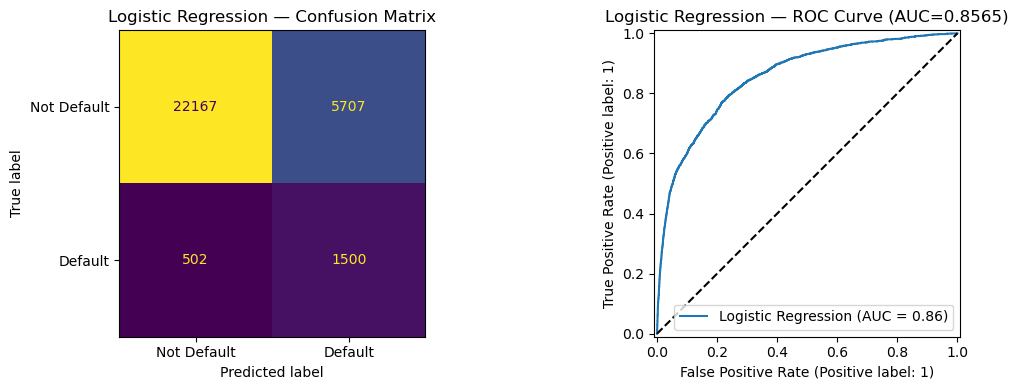


  MODEL: Random Forest

AUC-ROC  — Train: 0.9032 | Test: 0.8661

[Classification Report - TEST SET]
              precision    recall  f1-score   support

 Not Default       0.98      0.84      0.90     27874
     Default       0.25      0.72      0.37      2002

    accuracy                           0.83     29876
   macro avg       0.61      0.78      0.63     29876
weighted avg       0.93      0.83      0.87     29876



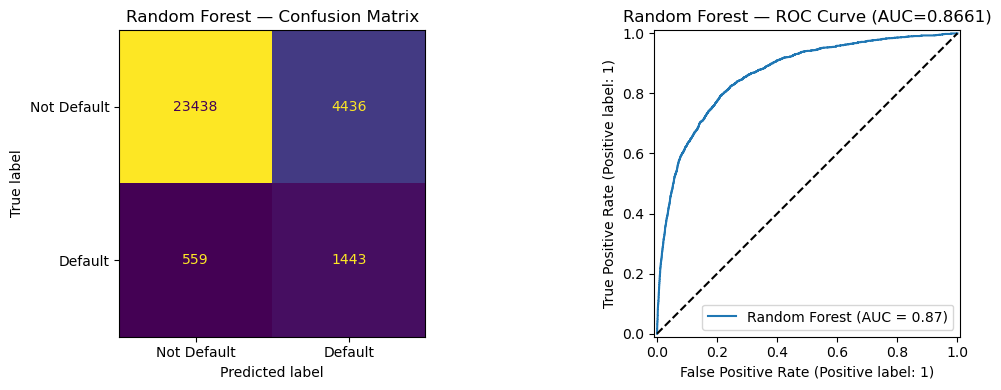


  MODEL: XGBoost

AUC-ROC  — Train: 0.9075 | Test: 0.8664

[Classification Report - TEST SET]
              precision    recall  f1-score   support

 Not Default       0.98      0.82      0.89     27874
     Default       0.23      0.75      0.35      2002

    accuracy                           0.82     29876
   macro avg       0.61      0.79      0.62     29876
weighted avg       0.93      0.82      0.86     29876



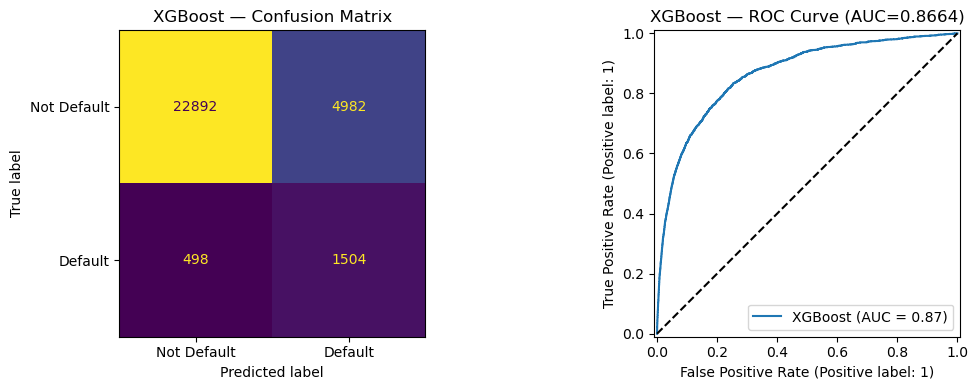


  MODEL: LightGBM

AUC-ROC  — Train: 0.9216 | Test: 0.8669

[Classification Report - TEST SET]
              precision    recall  f1-score   support

 Not Default       0.98      0.83      0.90     27874
     Default       0.24      0.74      0.36      2002

    accuracy                           0.82     29876
   macro avg       0.61      0.79      0.63     29876
weighted avg       0.93      0.82      0.86     29876



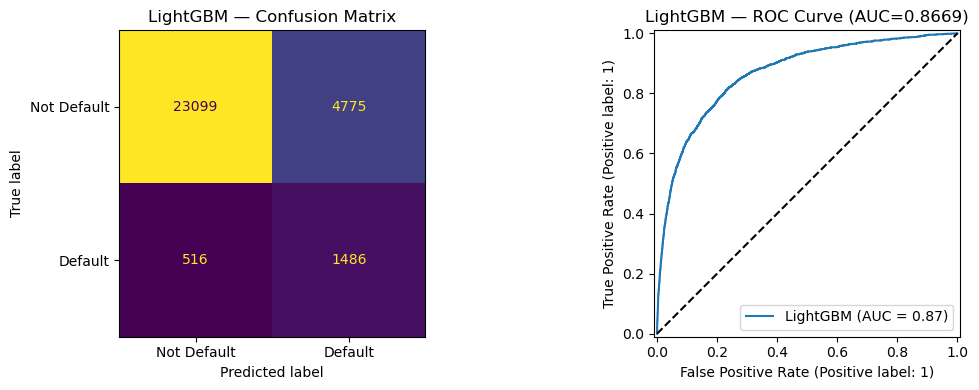

3735/3735 ━━━━━━━━━━━━━━━━━━━━ 3s 656us/step
934/934 ━━━━━━━━━━━━━━━━━━━━ 1s 627us/step

  MODEL: ANN

AUC-ROC  — Train: 0.6476 | Test: 0.6506

[Classification Report - TEST SET]
              precision    recall  f1-score   support

 Not Default       0.95      0.87      0.91     27874
     Default       0.19      0.40      0.25      2002

    accuracy                           0.84     29876
   macro avg       0.57      0.64      0.58     29876
weighted avg       0.90      0.84      0.87     29876



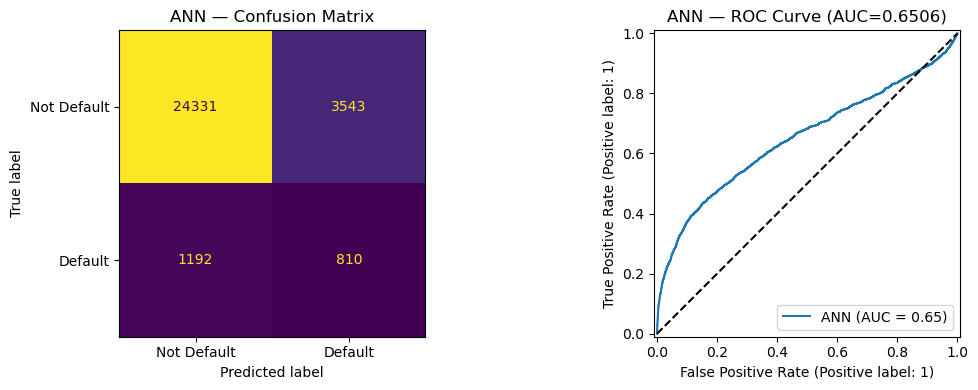

In [328]:
results = []

results.append(evaluate_model('Logistic Regression', model_lr, X_train_final, X_test_final, y_train, y_test))
results.append(evaluate_model('Random Forest', model_rf, X_train_final, X_test_final, y_train, y_test))
results.append(evaluate_model('XGBoost', model_xgb, X_train_final, X_test_final, y_train, y_test))
results.append(evaluate_model('LightGBM', model_lgbm, X_train_final, X_test_final, y_train, y_test))
results.append(evaluate_model('ANN', model_ann, X_train_final, X_test_final, y_train, y_test, is_ann=True))

In [330]:
results_df = pd.DataFrame(results).sort_values('AUC Test', ascending=False)
results_df

,Model,AUC Train,AUC Test,Recall Default (Test),F1 Default (Test),F1 Macro (Test)
3,LightGBM,0.9216,0.8669,0.7423,0.3597,0.6285
2,XGBoost,0.9075,0.8664,0.7512,0.3544,0.6237
1,Random Forest,0.9032,0.8661,0.7208,0.3662,0.6350
0,Logistic Regression,0.8494,0.8565,0.7493,0.3258,0.6015
4,ANN,0.6476,0.6506,0.4046,0.2549,0.5831


- Model berbasis tree (LightGBM, XGBoost, Random Forest) menghasilkan AUC terbaik dan serupa, menunjukkan kesesuaian tinggi untuk dataset ini
- **LightGBM** : keseimbangan terbaik antara ranking dan recall
  - AUC Test: 0.8669
  - Recall: 0.7423
  - F1: 0.3597
- **XGBoost** : recall sedikit lebih tinggi
  - AUC Test: 0.8664
  - Recall: 0.7512
  - F1: 0.3544
- **Random Forest** : prediksi paling seimbang
  - AUC Test: 0.8661
  - Recall: 0.7208
  - F1: 0.3662
- **Logistic Regression** : baseline kuat dengan fitur efektif
  - AUC Test: 0.8565
  - Recall: 0.7493
  - F1: 0.3258
- **ANN** : underfitting, tidak cocok untuk dataset terstruktur
  - AUC Test: 0.6506
  - Recall: 0.4046
  - F1: 0.2549

# IX. Model Training 2 - Hyperparameter Tuning

## 9.1. Model Definition and Training

In [331]:
lgbm = lgb.LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [300, 500, 800, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 5, 10, 15],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [0, 0.1, 0.5]
}

In [334]:
lgbm_random = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

lgbm_random.fit(X_train_final, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[LightGBM] [Info] Number of positive: 8006, number of negative: 111495
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1183
[LightGBM] [Info] Number of data points in the train set: 119501, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

RandomizedSearchCV(cv=3,
                   estimator=LGBMClassifier(class_weight='balanced', n_jobs=-1,
                                            random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [-1, 5, 10, 15],
                                        'min_child_samples': [10, 20, 30, 50],
                                        'n_estimators': [300, 500, 800, 1000],
                                        'num_leaves': [31, 63, 127],
                                        'reg_alpha': [0, 0.1, 0.5],
                                        'reg_lambda': [0, 0.1, 0.5],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [335]:
print("Best AUC:", lgbm_random.best_score_)
print("Best Params:", lgbm_random.best_params_)

Best AUC: 0.8637008496835122
Best Params: {'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0, 'num_leaves': 31, 'n_estimators': 800, 'min_child_samples': 50, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}


In [336]:
best_lgbm = lgbm_random.best_estimator_

best_lgbm.fit(X_train_final, y_train)

y_pred_proba = best_lgbm.predict_proba(X_test_final)[:, 1]

[LightGBM] [Info] Number of positive: 8006, number of negative: 111495
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000577 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1183
[LightGBM] [Info] Number of data points in the train set: 119501, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

## 9.2. Model Evaluation


  MODEL: Baseline LGBM

AUC-ROC  — Train: 0.9216 | Test: 0.8669

[Classification Report - TEST SET]
              precision    recall  f1-score   support

 Not Default       0.98      0.83      0.90     27874
     Default       0.24      0.74      0.36      2002

    accuracy                           0.82     29876
   macro avg       0.61      0.79      0.63     29876
weighted avg       0.93      0.82      0.86     29876



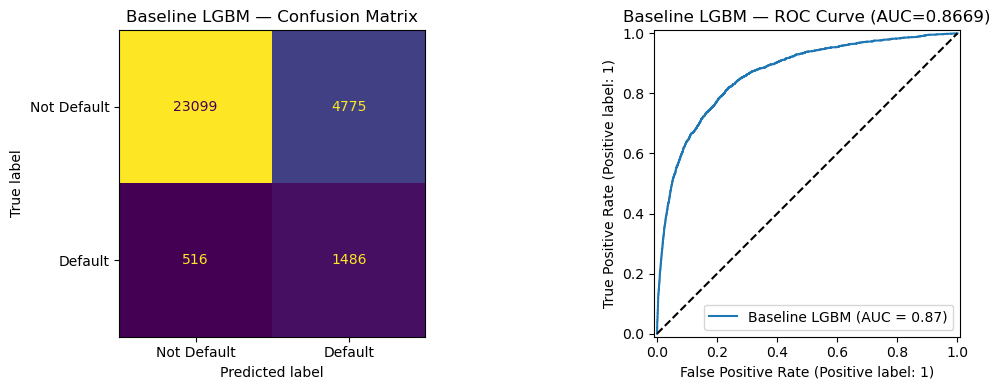


  MODEL: Tuned LGBM

AUC-ROC  — Train: 0.8802 | Test: 0.8702

[Classification Report - TEST SET]
              precision    recall  f1-score   support

 Not Default       0.98      0.81      0.88     27874
     Default       0.22      0.77      0.35      2002

    accuracy                           0.80     29876
   macro avg       0.60      0.79      0.62     29876
weighted avg       0.93      0.80      0.85     29876



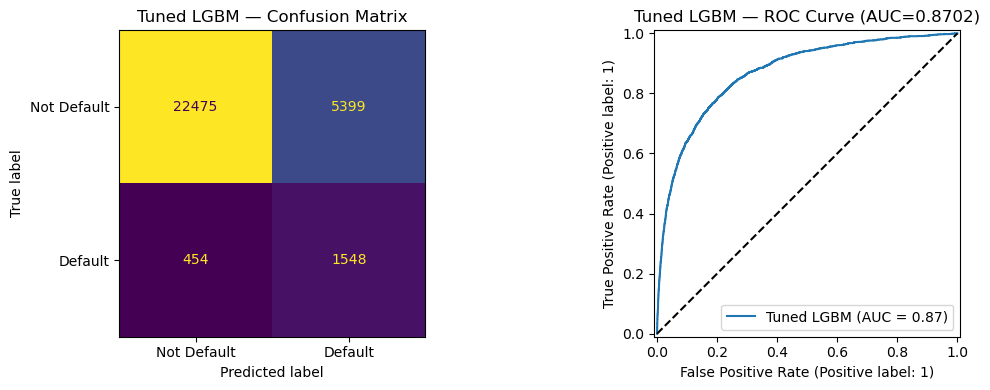

In [340]:
results_ht = []

results_ht.append(evaluate_model('Baseline LGBM', model_lgbm, X_train_final, X_test_final, y_train, y_test))
results_ht.append(evaluate_model('Tuned LGBM', best_lgbm, X_train_final, X_test_final, y_train, y_test))

In [341]:
results_ht_df = pd.DataFrame(results_ht)
results_ht_df

,Model,AUC Train,AUC Test,Recall Default (Test),F1 Default (Test),F1 Macro (Test)
0,Baseline LGBM,0.9216,0.8669,0.7423,0.3597,0.6285
1,Tuned LGBM,0.8802,0.8702,0.7732,0.3460,0.6154


- **Baseline LGBM** : Sedikit overfitting namun keseimbangan recall dan F1 score yang baik
  - AUC Train: 0.9216
  - AUC Test: 0.8669
  - Recall: 0.7423
  - F1: 0.3597
  - F1 Macro: 0.6285
- **Tuned LGBM** : Lebih baik dengan recall meningkat namun F1 sedikit turun
  - AUC Train: 0.8802
  - AUC Test: 0.8702
  - Recall: 0.7732
  - F1: 0.3460
  - F1 Macro: 0.6154
- Secara keseluruhan, tuning berhasil mengurangi overfitting dan meningkatkan generalisasi serta recall, dengan sedikit penurunan pada metrik F1 score.

### SHAP

In [345]:
import shap

explainer = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_train_final)

# Handle both cases (list or array)
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]  # class 1 (default)
else:
    shap_values_plot = shap_values

c:\Users\Konenhizer\anaconda3\envs\h8_env\lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


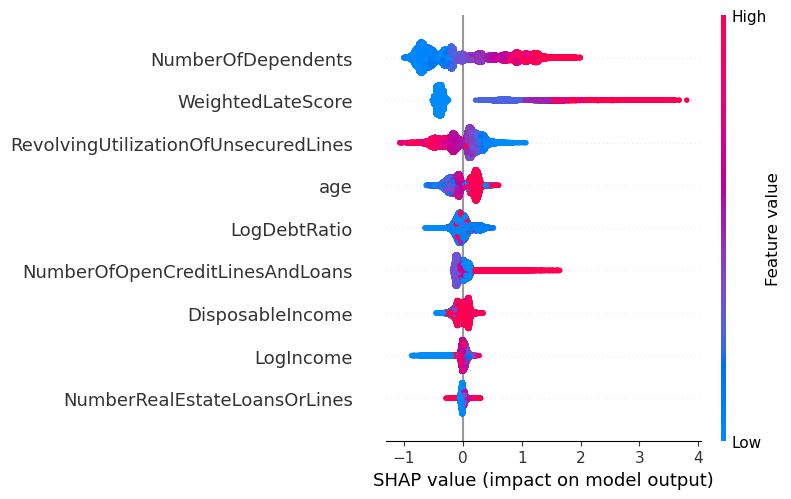

In [346]:
feature_names = X.columns  # or transformer.get_feature_names_out()

shap.summary_plot(
    shap_values_plot,
    X_train_final,
    feature_names=feature_names
)

- **NumberOfDependents** : Sangat berpengaruh namun perlu validasi karena keberadaan artefak data
  - Nilai tinggi meningkatkan risiko default secara signifikan
  - Nilai rendah mengurangi risiko
- **WeightedLateScore** : fitur paling berpengaruh dengan pola yang jelas
  - Keterlambatan pembayaran lebih banyak meningkatkan risiko default secara kuat
- **RevolvingUtilizationOfUnsecuredLines** : indikator tekanan keuangan yang kuat dan konsisten
  - Utilisasi tinggi meningkatkan risiko, utilisasi rendah mengurangi risiko
- **age** : Cukup memberikan pengaruh
  - Peminjam muda berisiko lebih tinggi, peminjam tua berisiko lebih rendah
- **LogDebtRatio** : pengaruh ada namun lebih lemah dibanding utilisasi
  - Beban utang tinggi meningkatkan risiko
- **NumberOfOpenCreditLinesAndLoans** : Sedikit meningkatkan risiko
- **DisposableIncome** : Peranan kecil
  - Surplus pendapatan tinggi mengurangi risiko
- **LogIncome** : Pengaruh lemah, menambah sedikit sinyal di luar fitur lain
- **NumberRealEstateLoansOrLines** : dampak minimal, kurang berguna untuk prediksi


Model terutama dipengaruhi oleh perilaku pembayaran (`WeightedLateScore`), penggunaan kredit (utilisasi), dan beban rumah tangga (jumlah tanggungan), sementara fitur kapasitas keuangan memiliki tingkat pengaruh di bawahnya.

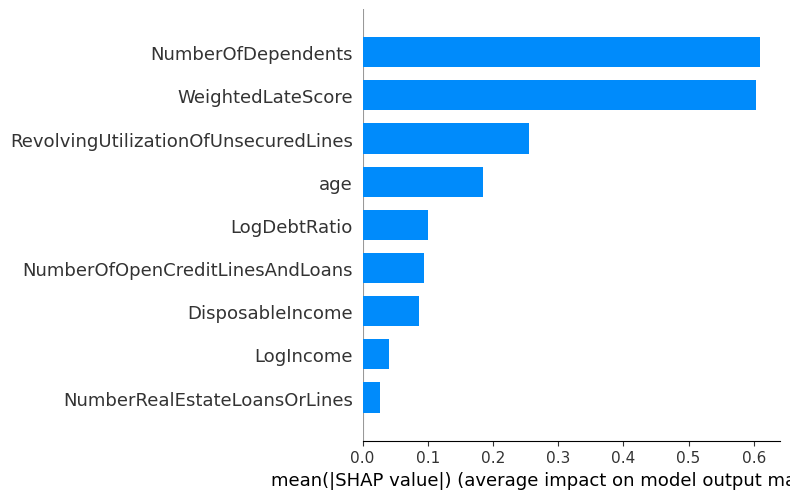

In [347]:
shap.summary_plot(
    shap_values_plot,
    X_train_final,
    feature_names=feature_names,
    plot_type="bar"
)

- **NumberOfDependents** dan **WeightedLateScore** mendominasi model sebagai pendorong risiko default terkuat, mencerminkan beban rumah tangga dan perilaku pembayaran
- **RevolvingUtilizationOfUnsecuredLines** menjadi fitur kunci berikutnya, mengonfirmasi utilisasi kredit sebagai sinyal risiko utama
- **age** Cukup berpengaruh, peminjam lebih tua umumnya berisiko lebih rendah
- **LogDebtRatio**, **NumberOfOpenCreditLinesAndLoans**, dan **DisposableIncome** berkontribusi namun bersifat sekunder, kapasitas keuangan kurang berpengaruh dibanding riwayat pembayaran
- **LogIncome** dan **NumberRealEstateLoansOrLines** memiliki dampak sangat kecil, menjadi kandidat kuat untuk dihapus dari model
- Kepentingan terkonsentrasi pada 3–4 fitur teratas, menunjukkan struktur keputusan model yang relatif sederhana

Posisi **NumberOfDependents** kemungkinan dipengaruhi oleh imputasi atau korelasi tidak langsung.

### KS-Statistics

In [348]:
# Example using best LightGBM
y_pred_proba = best_lgbm.predict_proba(X_test_final)[:, 1]

In [349]:
from scipy.stats import ks_2samp

# Split by class
good = y_pred_proba[y_test == 0]
bad = y_pred_proba[y_test == 1]

ks_stat, p_value = ks_2samp(bad, good)

print(f"KS Statistic: {ks_stat}")

KS Statistic: 0.5836207990904123


In [350]:
df_ks = pd.DataFrame({
    "y_true": y_test,
    "y_score": y_pred_proba
})

# Sort descending by score
df_ks = df_ks.sort_values(by="y_score", ascending=False).reset_index(drop=True)

# Create deciles
df_ks["decile"] = pd.qcut(df_ks.index, 10, labels=False)

# Aggregate
ks_table = df_ks.groupby("decile").agg(
    total=("y_true", "count"),
    bad=("y_true", "sum")
)

ks_table["good"] = ks_table["total"] - ks_table["bad"]

# Cumulative %
ks_table["cum_bad"] = ks_table["bad"].cumsum() / ks_table["bad"].sum()
ks_table["cum_good"] = ks_table["good"].cumsum() / ks_table["good"].sum()

# KS
ks_table["ks"] = np.abs(ks_table["cum_bad"] - ks_table["cum_good"])

print(ks_table)
print("\nKS Statistic:", ks_table["ks"].max())

        total   bad  good   cum_bad  cum_good        ks
decile                                                 
0        2988  1123  1865  0.560939  0.066908  0.494031
1        2988   355  2633  0.738262  0.161369  0.576893
2        2987   202  2785  0.839161  0.261283  0.577878
3        2988   106  2882  0.892108  0.364677  0.527431
4        2987    85  2902  0.934565  0.468788  0.465777
5        2988    42  2946  0.955544  0.574478  0.381066
6        2987    32  2955  0.971528  0.680491  0.291038
7        2988    27  2961  0.985015  0.786719  0.198296
8        2987    14  2973  0.992008  0.893377  0.098631
9        2988    16  2972  1.000000  1.000000  0.000000

KS Statistic: 0.5778779231817905


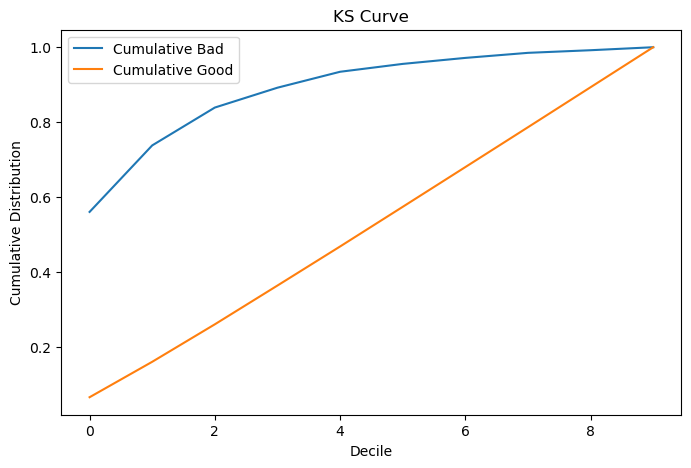

In [351]:
plt.figure(figsize=(8,5))

plt.plot(ks_table.index, ks_table["cum_bad"], label="Cumulative Bad")
plt.plot(ks_table.index, ks_table["cum_good"], label="Cumulative Good")

plt.title("KS Curve")
plt.xlabel("Decile")
plt.ylabel("Cumulative Distribution")
plt.legend()

plt.show()

- **KS Statistic: 0.5779**: Separasi model sangat kuat, bagus untuk credit risk
- Puncak KS pada **desil ke-2**: Model paling baik membedakan default vs non-default pada ~20–30% populasi berisiko tertinggi
- **Desil teratas (0)**: Menangkap ~56% dari seluruh default dengan hanya ~7% good, konsentrasi bad sangat tinggi untuk targeting nasabah berisiko
- **Desil awal (0–2)**: Menunjukkan peningkatan cepat cumulative bad vs lambatnya cumulative good, mengindikasikan ranking power yang kuat
- **Desil akhir**: Kurva konvergen, segmen risiko rendah menjadi tidak terdistingsi (perilaku yang diharapkan)
- **Bentuk kurva KS**: Separasi awal yang tajam menunjukkan model efektif memprioritaskan nasabah berisiko, konvergensi mulus tanpa instabilitas ranking
- **Implikasi bisnis**: Top 2–3 desil aman digunakan untuk penolakan kredit, manual review, dan risk-based pricing

Model siap produksi dari sisi perankingan, KS selaras dengan AUC (~0.87) yang mengonfirmasi performa kuat

# X. Model Saving

In [ ]:
with open("best_lgbm.pkl", "wb") as f:
    pickle.dump(best_lgbm, f)